In [1]:
# ============================================================
# Part 3 : Import Required Libraries
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve
)

import joblib

import warnings
warnings.filterwarnings("ignore")


# ============================================================
# Load Cleaned Dataset
# ============================================================

df = pd.read_csv("cleaned_data.csv")

print("Dataset Shape :", df.shape)

df.head()


# ============================================================
# Feature Matrix and Target
# ============================================================

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

target_column = numeric_columns[-1]

print("Target Column :", target_column)

X = df.drop(columns=[target_column])

y_reg = df[target_column]

y_clf = (y_reg > y_reg.median()).astype(int)


# ============================================================
# One Hot Encoding
# ============================================================

categorical_cols = X.select_dtypes(include=["object", "category"]).columns

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

print("Total Features :", X.shape[1])


# ============================================================
# Train Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)


# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Training Samples :", X_train_scaled.shape)
print("Testing Samples :", X_test_scaled.shape)


# ============================================================
# Decision Tree (Default)
# ============================================================

dt_default = DecisionTreeClassifier(
    random_state=42
)

dt_default.fit(
    X_train_scaled,
    y_train
)

train_pred = dt_default.predict(X_train_scaled)

test_pred = dt_default.predict(X_test_scaled)

train_accuracy = accuracy_score(
    y_train,
    train_pred
)

test_accuracy = accuracy_score(
    y_test,
    test_pred
)

print("="*50)
print("Decision Tree (Default)")
print("="*50)

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")


# ============================================================
# Controlled Decision Tree
# ============================================================

dt_controlled = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

dt_controlled.fit(
    X_train_scaled,
    y_train
)

train_pred = dt_controlled.predict(X_train_scaled)

test_pred = dt_controlled.predict(X_test_scaled)

train_accuracy = accuracy_score(
    y_train,
    train_pred
)

test_accuracy = accuracy_score(
    y_test,
    test_pred
)

print("="*50)
print("Controlled Decision Tree")
print("="*50)

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")


Dataset Shape : (278701, 39)
Target Column : ldl
Total Features : 251
Training Samples : (222960, 251)
Testing Samples : (55741, 251)
Decision Tree (Default)
Training Accuracy : 1.0000
Testing Accuracy  : 0.9999
Controlled Decision Tree
Training Accuracy : 0.9727
Testing Accuracy  : 0.9727


Gini vs Entropy
Gini Test Accuracy    : 0.9727
Entropy Test Accuracy : 0.9661
Random Forest Performance
Training Accuracy : 0.9968
Testing Accuracy  : 0.9966
ROC-AUC Score     : 1.0000
                         Feature  Importance
226     high_ldl_cholesterol_Yes    0.391298
13                   systolic_bp    0.038015
235  source_dataset_hypertension    0.033417
9                  triglycerides    0.028973
16                   salt_intake    0.028000


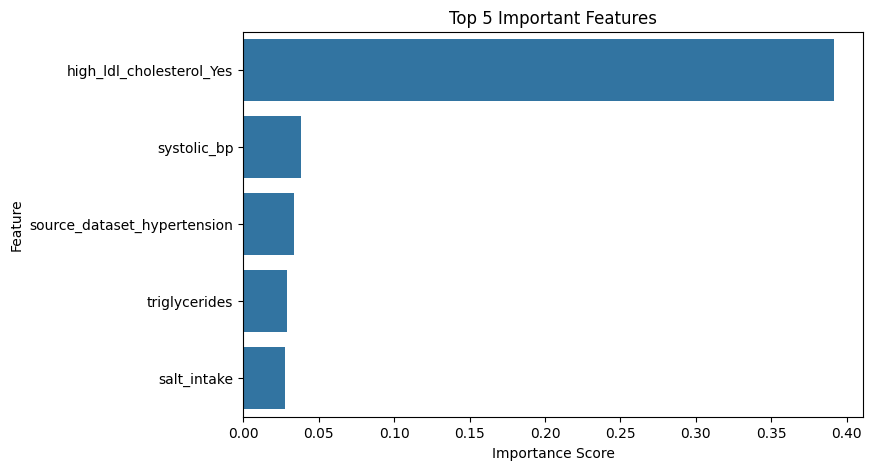

Gradient Boosting
Training Accuracy : 0.9850
Testing Accuracy  : 0.9840
ROC-AUC           : 0.9983
Lowest Importance Features
composite_key_Young_Female_Normal_Never_Yes
composite_key_Mature_Male_Underweight_Former_Yes
composite_key_Young_Male_Underweight_Never_Yes
composite_key_Middle_Male_Obese_Former_Yes
composite_key_Young_Male_Obese_Former_Yes


Feature Ablation Results
Full Model AUC    : 1.0000
Reduced Model AUC : 0.9999


In [2]:
# ============================================================
# Gini vs Entropy Decision Tree
# ============================================================

dt_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

dt_gini.fit(X_train_scaled, y_train)
dt_entropy.fit(X_train_scaled, y_train)

gini_pred = dt_gini.predict(X_test_scaled)
entropy_pred = dt_entropy.predict(X_test_scaled)

gini_acc = accuracy_score(y_test, gini_pred)
entropy_acc = accuracy_score(y_test, entropy_pred)

print("="*60)
print("Gini vs Entropy")
print("="*60)

print(f"Gini Test Accuracy    : {gini_acc:.4f}")
print(f"Entropy Test Accuracy : {entropy_acc:.4f}")


# ============================================================
# Random Forest
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

rf_train_pred = rf_model.predict(X_train_scaled)
rf_test_pred = rf_model.predict(X_test_scaled)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)

rf_prob = rf_model.predict_proba(X_test_scaled)[:,1]

rf_auc = roc_auc_score(y_test, rf_prob)

print("="*60)
print("Random Forest Performance")
print("="*60)

print(f"Training Accuracy : {rf_train_acc:.4f}")
print(f"Testing Accuracy  : {rf_test_acc:.4f}")
print(f"ROC-AUC Score     : {rf_auc:.4f}")


# ============================================================
# Feature Importance
# ============================================================

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

top5_features = importance_df.head(5)

print(top5_features)

plt.figure(figsize=(8,5))

sns.barplot(
    data=top5_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 5 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()


# ============================================================
# Gradient Boosting
# ============================================================

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(
    X_train_scaled,
    y_train
)

gb_train_pred = gb_model.predict(X_train_scaled)
gb_test_pred = gb_model.predict(X_test_scaled)

gb_train_acc = accuracy_score(
    y_train,
    gb_train_pred
)

gb_test_acc = accuracy_score(
    y_test,
    gb_test_pred
)

gb_prob = gb_model.predict_proba(
    X_test_scaled
)[:,1]

gb_auc = roc_auc_score(
    y_test,
    gb_prob
)

print("="*60)
print("Gradient Boosting")
print("="*60)

print(f"Training Accuracy : {gb_train_acc:.4f}")
print(f"Testing Accuracy  : {gb_test_acc:.4f}")
print(f"ROC-AUC           : {gb_auc:.4f}")


# ============================================================
# Feature Ablation
# ============================================================

lowest5 = importance_df.tail(5)["Feature"].tolist()

print("Lowest Importance Features")

for feature in lowest5:
    print(feature)

X_train_reduced = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
).drop(columns=lowest5)

X_test_reduced = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
).drop(columns=lowest5)

rf_reduced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_reduced.fit(
    X_train_reduced,
    y_train
)

reduced_prob = rf_reduced.predict_proba(
    X_test_reduced
)[:,1]

reduced_auc = roc_auc_score(
    y_test,
    reduced_prob
)

print("\n")
print("="*60)
print("Feature Ablation Results")
print("="*60)

print(f"Full Model AUC    : {rf_auc:.4f}")
print(f"Reduced Model AUC : {reduced_auc:.4f}")




In [4]:
# ============================================================
# Cross Validation
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )

}

cv_results = []

for name, model in models.items():

    scores = cross_val_score(

        model,

        X_train_scaled,

        y_train,

        cv=cv,

        scoring="roc_auc",

        n_jobs=1

    )

    cv_results.append([

        name,

        scores.mean(),

        scores.std()

    ])

cv_df = pd.DataFrame(

    cv_results,

    columns=[

        "Model",

        "Mean AUC",

        "Std AUC"

    ]

)

print(cv_df)

# ============================================================
# Pipeline
# ============================================================

pipeline = make_pipeline(

    SimpleImputer(strategy="median"),

    StandardScaler(),

    RandomForestClassifier(

        random_state=42,

        n_jobs=1

    )

)

# ============================================================
# Reduced Parameter Grid
# ============================================================

param_grid = {

    "randomforestclassifier__n_estimators":[100],

    "randomforestclassifier__max_depth":[10],

    "randomforestclassifier__min_samples_leaf":[1]

}

# ============================================================
# Grid Search
# ============================================================

grid = GridSearchCV(

    pipeline,

    param_grid=param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=1,

    verbose=2

)

grid.fit(

    X_train,

    y_train

)

print("="*60)

print("Best Parameters")

print(grid.best_params_)

print()

print("Best CV Score")

print(grid.best_score_)

# ============================================================
# Best Pipeline
# ============================================================

best_pipeline = grid.best_estimator_

# ============================================================
# Manual Learning Curve
# ============================================================

fractions = [0.2,0.4,0.6,0.8,1.0]

learning_curve = []

for frac in fractions:

    size = int(len(X_train)*frac)

    X_sub = X_train.iloc[:size]

    y_sub = y_train.iloc[:size]

    best_pipeline.fit(

        X_sub,

        y_sub

    )

    train_auc = roc_auc_score(

        y_sub,

        best_pipeline.predict_proba(X_sub)[:,1]

    )

    test_auc = roc_auc_score(

        y_test,

        best_pipeline.predict_proba(X_test)[:,1]

    )

    learning_curve.append([

        frac,

        train_auc,

        test_auc

    ])

learning_df = pd.DataFrame(

    learning_curve,

    columns=[

        "Training Fraction",

        "Training AUC",

        "Testing AUC"

    ]

)

print(learning_df)

# ============================================================
# Save Best Model
# ============================================================

joblib.dump(

    best_pipeline,

    "best_model.pkl"

)

print("\nModel Saved Successfully.")

# ============================================================
# Load Model
# ============================================================

loaded_model = joblib.load(

    "best_model.pkl"

)

sample_data = X_test.iloc[:2]

predictions = loaded_model.predict(

    sample_data

)

print("\nPredictions")

print(predictions)

# ============================================================
# Individual Model Evaluation
# ============================================================

rf_model = RandomForestClassifier(

    n_estimators=100,

    max_depth=10,

    random_state=42,

    n_jobs=1

)

rf_model.fit(

    X_train_scaled,

    y_train

)

rf_auc = roc_auc_score(

    y_test,

    rf_model.predict_proba(X_test_scaled)[:,1]

)

gb_model = GradientBoostingClassifier(

    n_estimators=100,

    learning_rate=0.1,

    random_state=42

)

gb_model.fit(

    X_train_scaled,

    y_train

)

gb_auc = roc_auc_score(

    y_test,

    gb_model.predict_proba(X_test_scaled)[:,1]

)

# ============================================================
# Comparison Table
# ============================================================

comparison = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest",

        "Gradient Boosting"

    ],

    "Test AUC":[

        roc_auc_score(

            y_test,

            LogisticRegression(max_iter=1000).fit(

                X_train_scaled,

                y_train

            ).predict_proba(

                X_test_scaled

            )[:,1]

        ),

        roc_auc_score(

            y_test,

            dt_controlled.predict_proba(

                X_test_scaled

            )[:,1]

        ),

        rf_auc,

        gb_auc

    ]

})

comparison = comparison.merge(

    cv_df,

    on="Model"

)

comparison = comparison.sort_values(

    by="Test AUC",

    ascending=False

)

print("\nFinal Comparison")

print(comparison)

                 Model  Mean AUC   Std AUC
0  Logistic Regression  0.986276  0.000506
1        Decision Tree  0.995671  0.000116
2        Random Forest  0.999965  0.000017
3    Gradient Boosting  0.998514  0.000252
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END randomforestclassifier__max_depth=10, randomforestclassifier__min_samples_leaf=1, randomforestclassifier__n_estimators=100; total time=  24.5s
[CV] END randomforestclassifier__max_depth=10, randomforestclassifier__min_samples_leaf=1, randomforestclassifier__n_estimators=100; total time=  24.0s
[CV] END randomforestclassifier__max_depth=10, randomforestclassifier__min_samples_leaf=1, randomforestclassifier__n_estimators=100; total time=  23.6s
[CV] END randomforestclassifier__max_depth=10, randomforestclassifier__min_samples_leaf=1, randomforestclassifier__n_estimators=100; total time=  24.7s
[CV] END randomforestclassifier__max_depth=10, randomforestclassifier__min_samples_leaf=1, randomforestclassifier__n_e